# Customer Churn / Sales Trend Analysis

**InternCircle Data Science Task 3**

This project performs an end-to-end analysis of an e-commerce sales dataset to identify revenue trends, customer segments, and indicators of customer retention/churn.


## 1. Import Libraries


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


## 2. Load the Dataset

This notebook uses the Online Retail dataset. It contains transaction-level e-commerce records with customer IDs, dates, quantities, and prices, which allows sales and customer-level analysis.


In [10]:
import pandas as pd
import requests
import zipfile
import io

# Download the Online Retail dataset from UCI
url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = requests.get(url)
response.raise_for_status()

# Open the downloaded ZIP file
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Files in dataset:", z.namelist())

    # Find the Excel file
    excel_file = [f for f in z.namelist() if f.endswith(".xlsx")][0]

    # Read Excel directly from the ZIP
    with z.open(excel_file) as f:
        df = pd.read_excel(f)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Files in dataset: ['Online Retail.xlsx']
Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Inspect and Clean the Data


In [11]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())


Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [12]:
# Standardize column names
# The public dataset uses InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

df = df.drop_duplicates().copy()
df = df.dropna(subset=['CustomerID', 'InvoiceDate'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print('Cleaned shape:', df.shape)
df.head()


Cleaned shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 4. Feature Engineering and Date Extraction


In [13]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Month_Name'] = df['InvoiceDate'].dt.strftime('%b')
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

df[['InvoiceDate', 'YearMonth', 'DayOfWeek', 'Quantity', 'UnitPrice', 'Revenue']].head()


,InvoiceDate,YearMonth,DayOfWeek,Quantity,UnitPrice,Revenue
0,2010-12-01 08:26:00,2010-12,Wednesday,6,2.55,15.30
1,2010-12-01 08:26:00,2010-12,Wednesday,6,3.39,20.34
2,2010-12-01 08:26:00,2010-12,Wednesday,8,2.75,22.00
3,2010-12-01 08:26:00,2010-12,Wednesday,6,3.39,20.34
4,2010-12-01 08:26:00,2010-12,Wednesday,6,3.39,20.34


## 5. Monthly Revenue Trend


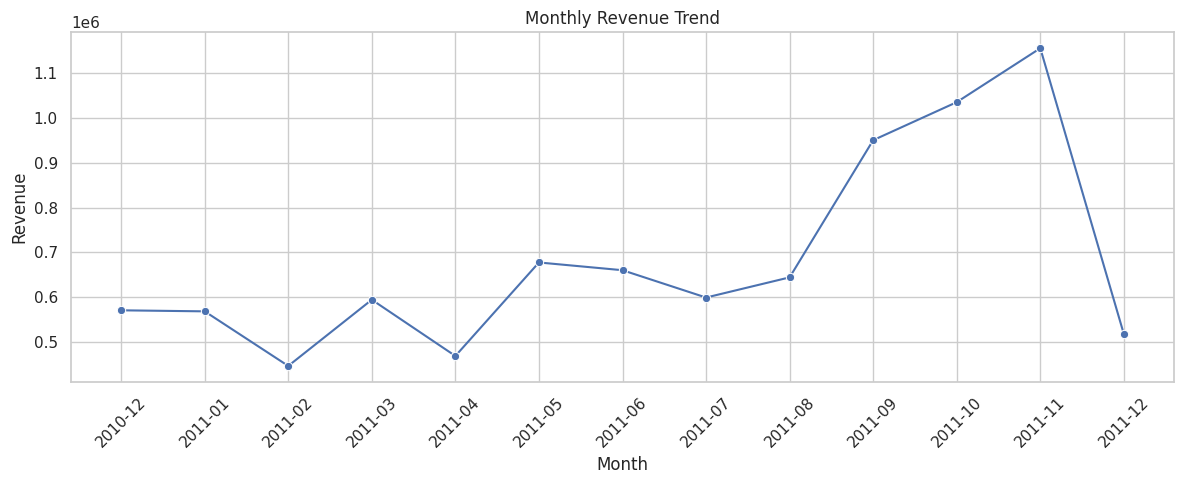

,YearMonth,Revenue
11,2011-11,1156205.610
10,2011-10,1035642.450
9,2011-09,950690.202
5,2011-05,677355.150
6,2011-06,660046.050
8,2011-08,644051.040
7,2011-07,598962.901
3,2011-03,594081.760
0,2010-12,570422.730
1,2011-01,568101.310


In [14]:
monthly_sales = df.groupby('YearMonth', as_index=False)['Revenue'].sum()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_sales.sort_values('Revenue', ascending=False).head(10)


## 6. Top Customer Segments


In [15]:
customer_summary = df.groupby('CustomerID').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'),
    TotalQuantity=('Quantity', 'sum'),
    LastPurchase=('InvoiceDate', 'max')
).reset_index()

customer_summary['AvgOrderValue'] = customer_summary['TotalRevenue'] / customer_summary['TotalOrders']
customer_summary.sort_values('TotalRevenue', ascending=False).head(10)


,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,LastPurchase,AvgOrderValue
1689,14646,280206.02,73,196915,2011-12-08 12:12:00,3838.438630
4201,18102,259657.30,60,64124,2011-12-09 11:50:00,4327.621667
3728,17450,194390.79,46,69973,2011-12-01 13:29:00,4225.886739
3008,16446,168472.50,2,80997,2011-12-09 09:15:00,84236.250000
1879,14911,143711.17,201,80240,2011-12-08 15:54:00,714.980945
55,12415,124914.53,21,77374,2011-11-15 14:22:00,5948.310952
1333,14156,117210.08,55,57768,2011-11-30 10:54:00,2131.092364
3771,17511,91062.38,31,64549,2011-12-07 10:12:00,2937.496129
2702,16029,80850.84,63,40108,2011-11-01 10:27:00,1283.346667
0,12346,77183.60,1,74215,2011-01-18 10:01:00,77183.600000


## 7. Customer Segmentation


In [16]:
# Segment customers using revenue and order frequency
revenue_q = customer_summary['TotalRevenue'].quantile([0.33, 0.66]).values
orders_q = customer_summary['TotalOrders'].quantile([0.33, 0.66]).values

def segment(row):
    if row['TotalRevenue'] >= revenue_q[1] and row['TotalOrders'] >= orders_q[1]:
        return 'High Value'
    elif row['TotalRevenue'] >= revenue_q[0] or row['TotalOrders'] >= orders_q[0]:
        return 'Medium Value'
    return 'Low Value'

customer_summary['Segment'] = customer_summary.apply(segment, axis=1)
customer_summary['Segment'].value_counts()


,count
Segment,
Medium Value,3163
High Value,1175


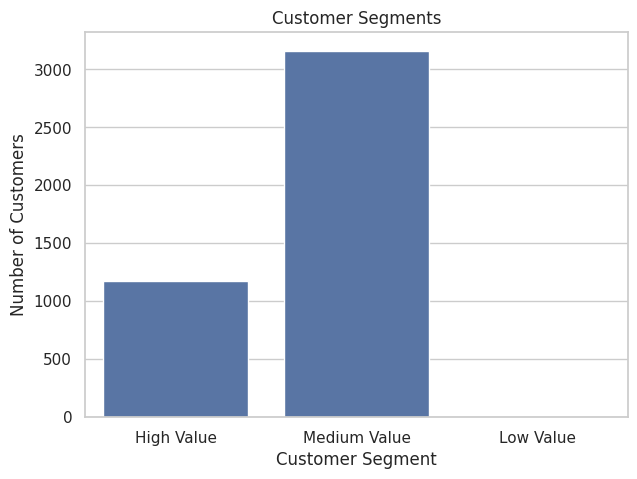

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(data=customer_summary, x='Segment', order=['High Value', 'Medium Value', 'Low Value'])
plt.title('Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.show()


## 8. Recency / Churn Indicator

A true churn label is not directly provided in this transaction dataset. Instead, we create a **recency-based inactivity indicator**. Customers whose last purchase is sufficiently old relative to the latest transaction date are flagged as inactive. This is an analytical proxy, not a confirmed churn label.


In [18]:
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
customer_summary['RecencyDays'] = (analysis_date - customer_summary['LastPurchase']).dt.days

# 90+ days without a purchase is used as an illustrative inactivity threshold.
customer_summary['Inactive_90_Days'] = customer_summary['RecencyDays'] >= 90

customer_summary[['CustomerID', 'RecencyDays', 'Inactive_90_Days', 'Segment']].head()


,CustomerID,RecencyDays,Inactive_90_Days,Segment
0,12346,326,True,Medium Value
1,12347,2,False,High Value
2,12348,75,False,High Value
3,12349,19,False,Medium Value
4,12350,310,True,Medium Value


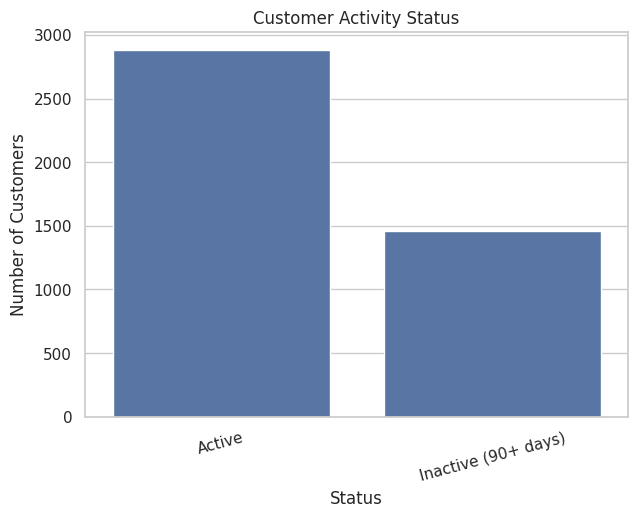

,count
Inactive_90_Days,
Active,2880
Inactive (90+ days),1458


In [19]:
inactivity = customer_summary['Inactive_90_Days'].value_counts().rename(index={False: 'Active', True: 'Inactive (90+ days)'})

plt.figure(figsize=(7, 5))
sns.barplot(x=inactivity.index, y=inactivity.values)
plt.title('Customer Activity Status')
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.show()

inactivity


## 9. Pivot Table Analysis


In [20]:
pivot_sales = pd.pivot_table(
    df,
    index='YearMonth',
    columns='Country',
    values='Revenue',
    aggfunc='sum',
    fill_value=0
)

pivot_sales.head()


Country,Australia,Austria,Bahrain,Belgium,Brazil,Canada,Channel Islands,Cyprus,Czech Republic,Denmark,...,RSA,Saudi Arabia,Singapore,Spain,Sweden,Switzerland,USA,United Arab Emirates,United Kingdom,Unspecified
YearMonth,,,,,,,,,,,,,,,,,,,,,
2010-12,965.35,277.20,0.0,1809.91,0.0,0.00,363.53,1587.07,0.00,1281.50,...,0.0,0.00,0.00,1843.73,3834.30,1304.92,0.00,0.00,496477.340,0.0
2011-01,9017.71,0.00,0.0,1200.20,0.0,0.00,675.58,547.50,0.00,0.00,...,0.0,0.00,2053.07,10086.09,3486.32,4231.23,0.00,0.00,440876.330,0.0
2011-02,14695.42,518.36,0.0,2181.07,0.0,0.00,1784.71,4334.24,549.26,399.22,...,0.0,145.92,0.00,2114.50,509.50,2654.92,0.00,889.24,354618.200,0.0
2011-03,17223.99,1708.12,0.0,3351.98,0.0,140.54,3509.33,938.39,0.00,3978.99,...,0.0,0.00,0.00,5363.15,4720.58,1870.23,0.00,0.00,465784.190,0.0
2011-04,771.60,680.78,0.0,1989.48,1143.6,0.00,293.00,0.00,0.00,0.00,...,0.0,0.00,8209.58,1785.65,809.10,2076.94,383.95,0.00,408733.111,299.1


## 10. Top Products by Revenue


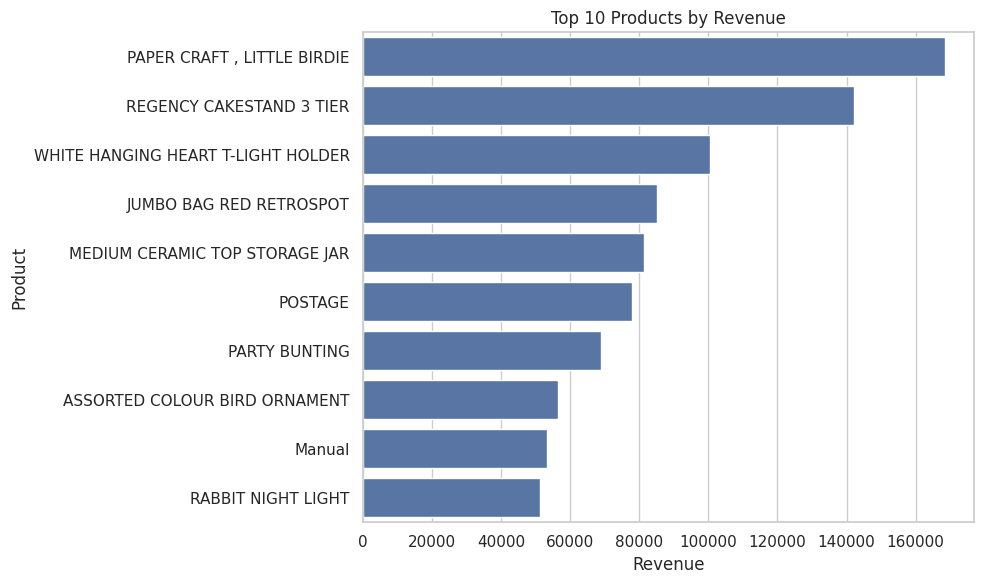

In [21]:
product_sales = df.groupby('Description', as_index=False)['Revenue'].sum()
product_sales = product_sales.sort_values('Revenue', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=product_sales, y='Description', x='Revenue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


## 11. Business Recommendations

1. **Retain high-value customers:** Use loyalty offers and personalized recommendations for customers with high revenue and frequent purchases.
2. **Re-engage inactive customers:** Customers inactive for 90+ days can be targeted with reminders, discounts, or personalized campaigns.
3. **Track monthly revenue:** Monitor month-over-month changes to identify strong periods and investigate unusual declines.
4. **Prioritize high-performing products:** Maintain availability of products that consistently contribute significant revenue.
5. **Use customer segmentation:** Different offers can be designed for high-, medium-, and low-value customer groups rather than using one strategy for everyone.


## Conclusion

The analysis combines data cleaning, date extraction, revenue calculations, customer segmentation, pivot-table analysis, and a recency-based inactivity indicator. It demonstrates how transaction-level e-commerce data can be transformed into practical business insights.
